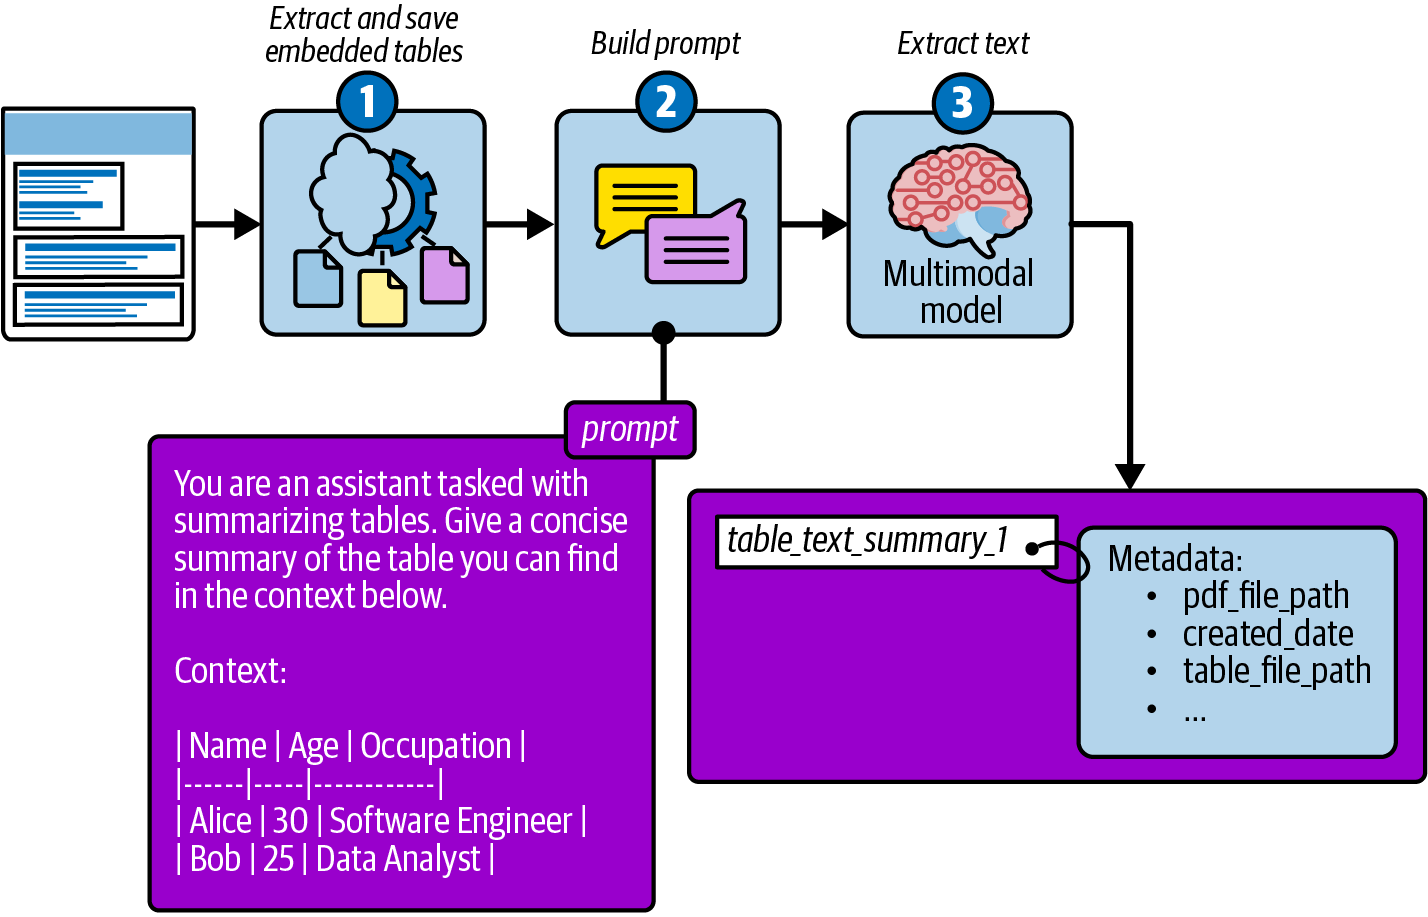

In [1]:
from IPython.display import Image, display
display(Image(filename="../images/17.png", width=500, height=500))

In [ ]:
pip install unstructured openai pandas

In [ ]:
import os
from unstructured.partition.pdf import partition_pdf

pdf_file_path = "../datasets/pdf_files/adult_data_article.pdf"

tables = []
texts = []

# Partition the PDF file into its elements
raw_pdf_elements = partition_pdf(
    filename=pdf_file_path,
    strategy="hi_res",
)

for element in raw_pdf_elements:
    if "unstructured.documents.elements.Table" in str(type(element)):
        tables.append(str(element))

In [ ]:
from openai import OpenAI
import pandas as pd


def summarize_tables(row):
    summary_prompt = (
        f"You are an assistant tasked with summarizing tables. "
        f"Give a concise summary of the table. "
        f"Table chunk: {row.table}"
    )

    # Initialize the OpenAI API client and generate table summary
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    response = client.chat.completions.create(
        model="gpt-5-mini",
        messages=[{"role": "user", "content": summary_prompt}],
        temperature=0.7,
        max_tokens=150,
    )

    row["table_summary"] = response.choices[0].message.content

    return row
# Create a pandas dataframe from the tables
tables_df = pd.DataFrame(tables, columns=["table"])

# Add a column to the dataframe to store the summaries
tables_df = tables_df.apply(summarize_tables, axis=1)